RectBivariateSpline from Scipy

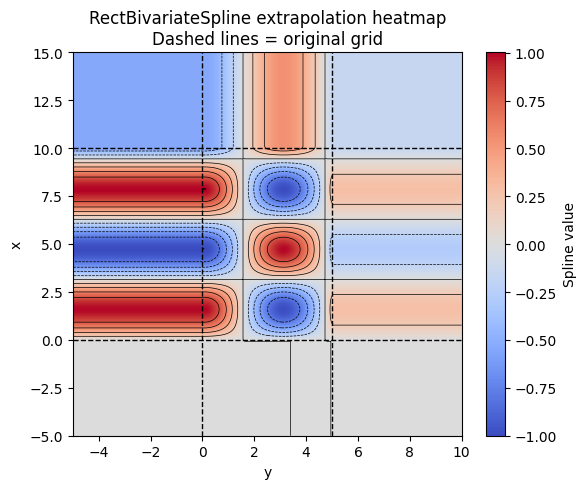

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

# base grid for the spline
x = np.linspace(0, 10, 11)
y = np.linspace(0, 5, 6)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.sin(X) * np.cos(Y)   # smooth function

# fit spline
spline = RectBivariateSpline(x, y, Z)

# bigger grid to view extrapolation
x_new = np.linspace(-5, 15, 200)     # extends beyond [0,10]
y_new = np.linspace(-5, 10, 200)     # extends beyond [0,5]
Z_new = spline(x_new, y_new)

# plot
plt.figure(figsize=(6,5))

extent = [y_new.min(), y_new.max(), x_new.min(), x_new.max()]
plt.imshow(Z_new, extent=extent, origin='lower', aspect='auto', cmap='coolwarm')
plt.colorbar(label='Spline value')

# contours for detail
plt.contour(y_new, x_new, Z_new, levels=10, colors='k', linewidths=0.5)

# draw original domain rectangle
plt.axvline(y.min(), color='k', linestyle='--', linewidth=1)
plt.axvline(y.max(), color='k', linestyle='--', linewidth=1)
plt.axhline(x.min(), color='k', linestyle='--', linewidth=1)
plt.axhline(x.max(), color='k', linestyle='--', linewidth=1)

plt.title("RectBivariateSpline extrapolation heatmap\nDashed lines = original grid")
plt.xlabel("y")
plt.ylabel("x")
plt.tight_layout()
plt.show()


Exercise: Find all roots of the function for using scipy or any other package you like.https://researchcomputing.readthedocs.io/en/stable/material/part11/notebook.html#Basic-matrix-operations 

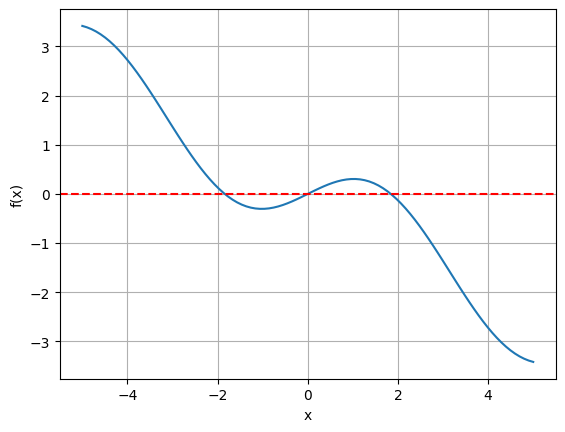

In [15]:
import matplotlib.pyplot as plt
# Define a single-variable function with y fixed
def f(x, a, b):
    return np.sin(x) * np.cos(a) - b*x


# Create a grid of x values
x = np.linspace(-5, 5, 100)

# Evaluate f for a=0.3, b=0.5
y = f(x, 0.3, 0.5)

# Plot
plt.figure()
plt.plot(x, y)
plt.grid(True)
plt.xlabel('x')
plt.ylabel('f(x)')

plt.axhline(y=0, color='r', linestyle='--')


In [16]:
import scipy

# Set the value of a, b to fix
a=0.3
b=0.5

# Use brentq to find the root of f with respect to x for the fixed a, b
# Provide an interval [a, b] where f(x, a, b) changes sign
x_root = scipy.optimize.brentq(f, 1, 2, args=(a,b))

print("Root found for x with a, b fixed at", a, b, ":", x_root)

Root found for x with a, b fixed at 0.3 0.5 : 1.8412298808552796


In [24]:
import numpy as np
from scipy.optimize import brentq

def find_multiple_roots(f, lo, hi, step=1.0, tol=1e-6):
    xs = np.arange(lo, hi + step, step)   # inclusive of hi
    roots = []

    for i in range(len(xs) - 1):
        x_i = xs[i]
        x_j = xs[i + 1]

        f_i = f(x_i)
        f_j = f(x_j)

        if abs(f_i) < tol:
            roots.append(x_i)
            continue

        if f_i * f_j < 0:
            root = brentq(f, x_i, x_j)
            # de-duplicate close roots
            if not roots or all(abs(root - r) > 1e-6 for r in roots):
                roots.append(root)

    # right-endpoint check
    if abs(f(xs[-1])) < tol:
        roots.append(xs[-1])

    return roots


In [25]:
a = 0.3
b = 0.5

def f(x): 
    return np.sin(x) * np.cos(a) - b*x

roots = find_multiple_roots(f, -4, 4, step=1.0)
print("Roots for a,b =", a, b, ":", roots)


Roots for a,b = 0.3 0.5 : [-1.8412298808552796, np.float64(0.0), 1.8412298808552796]


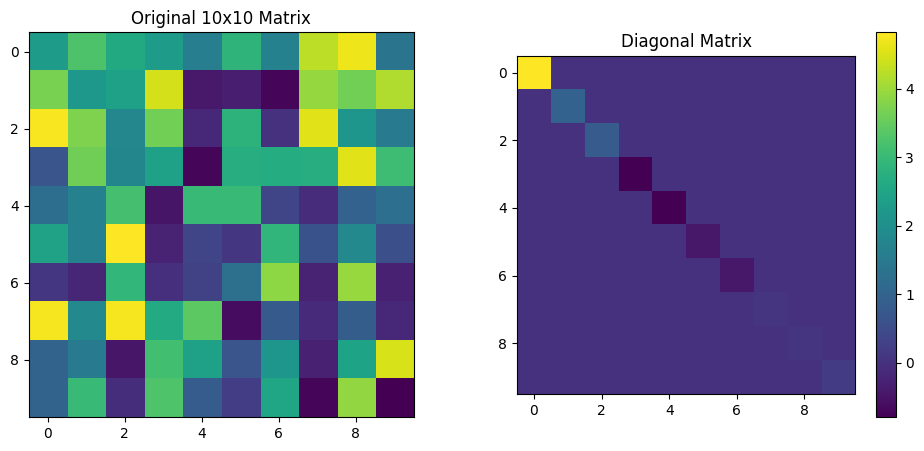

0.012191309322200517
Trace of original matrix: 4.457529730942303
Trace of (real) diagonal matrix: 4.457529730942311
Trace of (imaginary) diagonal matrix: 0.0


In [38]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Create a random 10x10 matrix for demonstration
np.random.seed(0)
matrix = np.random.rand(10, 10)

# Calculate the inverse, determinant, and eigenvalues/eigenvectors
matrix_inv = la.inv(matrix)
det = la.det(matrix)
eigvals, eigvecs = la.eig(matrix)

# Diagonalized matrix: D = V^-1 * A * V (where V is the eigenvector matrix)
# This reconstructs the diagonal form using the eigenvalues
diagonal_matrix = np.diag(eigvals.real)  # Only real part for visualization
imaginary_diagonal_matrix = np.diag(eigvals.imag)  # imaginary part
# Plotting the original and diagonalized matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Show original matrix
axs[0].imshow(matrix, cmap="viridis")
axs[0].set_title("Original 10x10 Matrix")

# Show diagonalized matrix
axs[1].imshow(diagonal_matrix, cmap="viridis")
axs[1].set_title("Diagonalized Matrix (Eigenvalues on Diagonal)")

# Add subplot for eigenvector matrix
axs[1].set_title("Diagonal Matrix")
plt.colorbar(axs[1].imshow(diagonal_matrix, cmap="viridis"), ax=axs[1])

plt.show()

# Output determinant for reference
print(det)

# Calculate and print traces
print(f"Trace of original matrix: {np.trace(matrix)}")
print(f"Trace of (real) diagonal matrix: {np.trace(diagonal_matrix)}")
print(f"Trace of (imaginary) diagonal matrix: {np.trace(imaginary_diagonal_matrix)}")

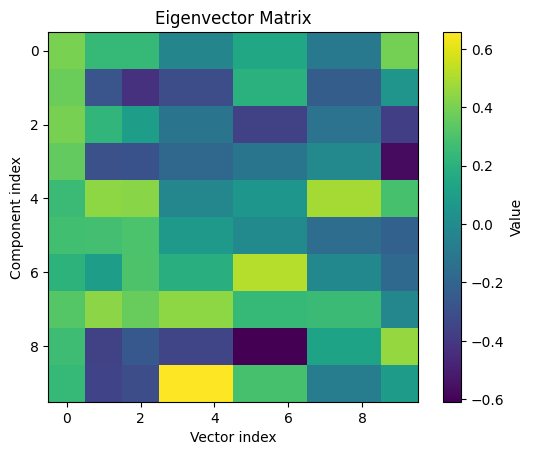

Are eigenvectors orthonormal? False


In [30]:
import matplotlib.pyplot as plt

# Suppose eigvecs is your matrix of eigenvectors
plt.imshow(eigvecs.real, cmap="viridis")  # show the real part
plt.colorbar(label="Value")
plt.title("Eigenvector Matrix")
plt.xlabel("Vector index")
plt.ylabel("Component index")
plt.show()
# Suppose eigvecs is your matrix of eigenvectors
check = np.allclose(eigvecs.conj().T @ eigvecs, np.eye(eigvecs.shape[0]))
print("Are eigenvectors orthonormal?", check)

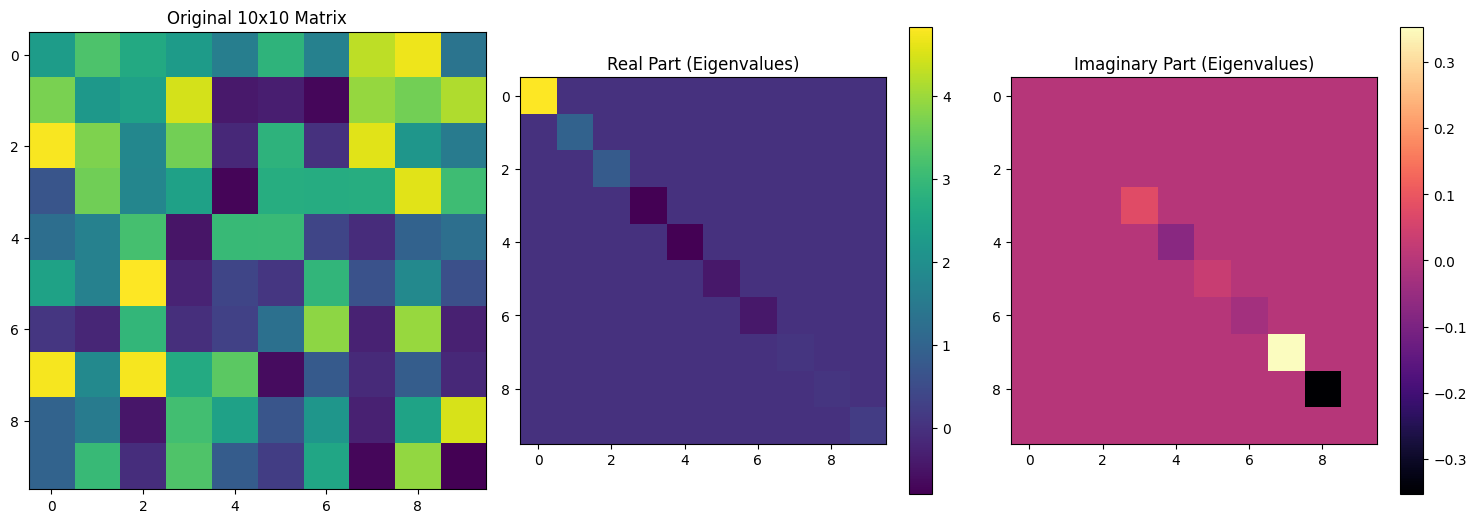

Trace of real diagonal matrix: 4.457529730942311
Trace of imaginary diagonal matrix: 0.0


In [37]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Create a random 10x10 matrix
np.random.seed(0)
matrix = np.random.rand(10, 10)

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = la.eig(matrix)

# Separate real and imaginary parts of eigenvalues
real_diag = np.diag(eigvals.real)
imag_diag = np.diag(eigvals.imag)

# Plot both diagonal matrices
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original matrix
axs[0].imshow(matrix, cmap="viridis")
axs[0].set_title("Original 10x10 Matrix")

# Real diagonal matrix
im1 = axs[1].imshow(real_diag, cmap="viridis")
axs[1].set_title("Real Part (Eigenvalues)")
plt.colorbar(im1, ax=axs[1])

# Imaginary diagonal matrix
im2 = axs[2].imshow(imag_diag, cmap="magma")
axs[2].set_title("Imaginary Part (Eigenvalues)")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

# Print trace values for clarity
print(f"Trace of real diagonal matrix: {np.trace(real_diag)}")
print(f"Trace of imaginary diagonal matrix: {np.trace(imag_diag)}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox

# Function to generate a sawtooth signal
def generate_sawtooth_pattern(length=200, period=50):
    return np.tile(np.linspace(-1, 1, period), length // period)

# Function to create a Gaussian kernel
def gaussian_kernel(size=21, sigma=3.0):
    """
    Generate a Gaussian kernel.
    - Adjust the `size` parameter to control the width of the kernel.
    - Adjust the `sigma` parameter to control the amplitude (spread) of the kernel.
    """
    kernel = np.linspace(-(size // 2), size // 2, size)
    kernel = np.exp(-kernel**2 / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)  # Normalize
    return kernel

# Function to perform 1D convolution (valid mode)
def convolve_1d(input_array, kernel):
    return np.convolve(input_array, kernel, mode='valid')

# Function to visualize the convolution process
def plot_convolution(step, input_array, kernel, result, save_as_svg):
    kernel_size = len(kernel)
    input_size = len(input_array)

    fig, axs = plt.subplots(3, 1, figsize=(9, 7))

    # Plot the input signal (Sawtooth)
    axs[0].plot(range(input_size), input_array, ls='-',lw=0.5,marker='o',markersize=0.3)
    axs[0].set_title('Input Array (Sawtooth Signal)')
    axs[0].set_xlim(0, input_size - 1)

    # Plot the kernel centered at the current step
    axs[1].stem(range(step, step + kernel_size), kernel, basefmt=" ", linefmt='None', markerfmt='C1o')
    axs[1].set_title(f'Gaussian Kernel')
    axs[1].set_xlim(0, input_size - 1)

    # Plot the result up to the current step
    axs[2].plot(range(len(result)), result, 'C2-')
    axs[2].set_title('Result of Convolution')
    axs[2].set_xlim(0, input_size - kernel_size)


    plt.tight_layout()


    # Save the plot as an SVG if requested
    if save_as_svg:
        plt.savefig('1dconv_sawtooth_plot.svg', format='svg')
        print("Plot saved as '1dconv_sawtooth_plot.svg'")


    plt.show()

# Interactive function
def interactive_convolution(step, size, sigma, save_as_svg=False):
    input_array = generate_sawtooth_pattern(length=200, period=50)  # More points, sawtooth pattern
    kernel = gaussian_kernel(size=size, sigma=sigma)  # Adjust width and amplitude here
    result = convolve_1d(input_array, kernel)
    plot_convolution(step, input_array, kernel, result[:step+1],save_as_svg)

# Create interactive sliders for convolution steps, kernel size (width), and kernel sigma (amplitude)
input_array = generate_sawtooth_pattern(length=200, period=50)

interact(
    interactive_convolution,
    step=IntSlider(min=0, max=len(convolve_1d(input_array, gaussian_kernel(21, 3.0))) - 1, step=1, value=0),
    size=IntSlider(min=3, max=51, step=2, value=21, description='Kernel Size'),
    sigma=FloatSlider(min=0.1, max=10.0, step=0.1, value=3.0, description='Sigma'),
    save_as_svg=Checkbox(value=False, description='Save as SVG')
)